In [1]:
import tensorflow as tf
import datetime

print("tensorflow version" , tf.__version__)
print("Date and time :" , datetime.datetime.now())

tensorflow version 2.19.0
Date and time : 2025-11-19 17:12:42.831618


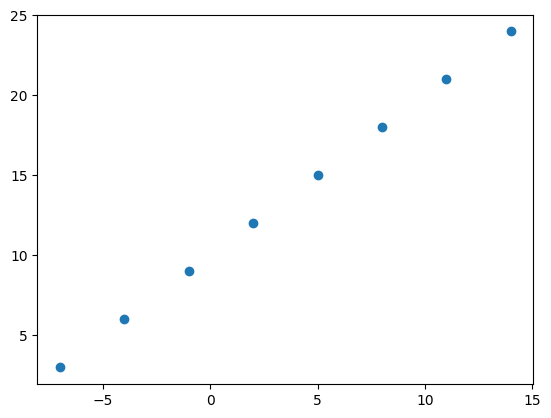

In [2]:
# creating the data
import numpy as np
import matplotlib.pyplot as plt

# create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])
# create lables
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# visualize
plt.scatter(X,y)

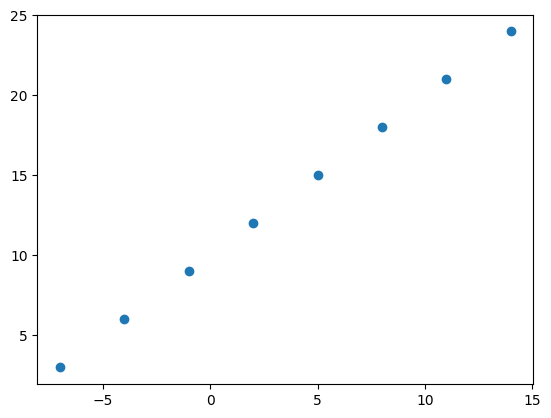

In [3]:

# Create features (using tensors)
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels (using tensors)
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y);

In TensorFlow, there are typically 3 fundamental steps to creating and training a model.

1. Creating a model - piece together the layers of a neural network yourself (using the Functional or Sequential API) or import a previously built model (known as transfer learning).

2. Compiling a model - defining how a models performance should be measured (loss/metrics) as well as defining how it should improve (optimizer).

3. Fitting a model - letting the model try to find patterns in the data (how does X get to y).

In [4]:
tf.random.set_seed(123)

# create the model
model =  tf.keras.Sequential([
    tf.keras.layers.Dense(64 , activation="relu" , input_shape =[1,]),
    tf.keras.layers.Dense(16 , activation="relu"),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(
    # this is the loss fn
    loss = tf.keras.losses.mae,
    # optimizer
    optimizer = tf.keras.optimizers.SGD(),
    # matrices
    metrics = ["mae"]
)

# fit the model
model.fit(
    
    tf.expand_dims(X , axis=-1) #Keras expects input data in a 2D shape for batches (samples x features), even if there's only one feature.
    
    ,y , epochs=5)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 632ms/step - loss: 13.6031 - mae: 13.6031
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 13.3415 - mae: 13.3415
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 13.0925 - mae: 13.0925
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 12.8403 - mae: 12.8403
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 12.5493 - mae: 12.5493


In [5]:
# Set random seed
tf.random.set_seed(42)

# Create a model using the Sequential API
model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(loss=tf.keras.losses.mae, # mae is short for mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # SGD is short for stochastic gradient descent
              metrics=["mae"])

# Fit the model
# model.fit(X, y, epochs=5) # this will break with TensorFlow 2.7.0+
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - loss: 18.2894 - mae: 18.2894
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 18.0081 - mae: 18.0081
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 17.7269 - mae: 17.7269
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 17.4456 - mae: 17.4456
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 17.1644 - mae: 17.1644


In [6]:
for x in X:
    print(x)
    # model.predict(x)  

tf.Tensor(-7.0, shape=(), dtype=float32)
tf.Tensor(-4.0, shape=(), dtype=float32)
tf.Tensor(-1.0, shape=(), dtype=float32)
tf.Tensor(2.0, shape=(), dtype=float32)
tf.Tensor(5.0, shape=(), dtype=float32)
tf.Tensor(8.0, shape=(), dtype=float32)
tf.Tensor(11.0, shape=(), dtype=float32)
tf.Tensor(14.0, shape=(), dtype=float32)


In [7]:
X,y,X[0]

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>,
 <tf.Tensor: shape=(), dtype=float32, numpy=-7.0>)

In [8]:
model.predict(X, batch_size=None, verbose="auto", steps=None, callbacks=None)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[  5.585807 ],
       [  3.207961 ],
       [  0.8301153],
       [ -1.5477306],
       [ -3.9255767],
       [ -6.3034225],
       [ -8.681268 ],
       [-11.0591135]], dtype=float32)

In [10]:
sample1=  tf.constant([[2]])
sample2= np.array([[2]])
sample3 = [[2]]

In [11]:
model.predict(sample1) , model.predict(sample2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


(array([[-1.5477306]], dtype=float32), array([[-1.5477306]], dtype=float32))

In [14]:
model.predict(tf.constant([[17]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[-13.436959]], dtype=float32)

In [27]:
tf.random.set_seed(1234)

# create the model
model2 =  tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# compile
model2.compile(
    
    loss=tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),           
    metrics = ['mae']
)

# fit
model2.fit(tf.expand_dims(X , axis= -1) , y , epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - loss: 20.5896 - mae: 20.5896
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 20.3084 - mae: 20.3084
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 20.0271 - mae: 20.0271
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 19.7459 - mae: 19.7459
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 19.4646 - mae: 19.4646
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 19.1834 - mae: 19.1834
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 18.9021 - mae: 18.9021
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 18.6209 - mae: 18.6209
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 18.3396 - mae: 18.3396
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 18.0584 - mae: 18.0584
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 17.7771 - mae: 17.7771
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 17.4959 - mae: 17.4959
Epoch 13/100
1/1 ━━━━━━━

In [28]:
model2.predict(tf.constant([[17]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


array([[29.359568]], dtype=float32)